In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
masers = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/w51_irs2_ammonia_maser_spectral_spatial_fits.csv')
sources = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/FK5_ICRS_offsets/offset_sources.csv')

In [3]:
#fig, ax = plt.subplots(figsize=(8, 8))

d2_vlsr = masers[(masers['source'] == 'd2')]['vlsr_kms']
d2_vlsr_err = masers[(masers['source'] == 'd2')]['vlsr_kms_err']

d2_x = masers[(masers['source'] == 'd2')]['x_mean_sky']
d2_y = masers[(masers['source'] == 'd2')]['y_mean_sky']

d2_ALMA_x_sky = sources[((sources['source'] == 'd2') & (sources['freq'] == '90 GHz'))]['x_mean_sky']
d2_ALMA_y_sky = sources[((sources['source'] == 'd2') & (sources['freq'] == '90 GHz'))]['y_mean_sky']

delta_y = float(d2_ALMA_y_sky) - d2_y
delta_x = float(d2_ALMA_x_sky) - d2_x

distance_from_d2 = np.sqrt(delta_x**2 + delta_y**2) * u.deg.to(u.arcsec)
print(f"Distance from d2 to ALMA: {distance_from_d2} ")


Distance from d2 to ALMA: 9     0.054936
10    0.056681
11    0.042768
12    0.055417
13    0.061374
14    0.044260
15    0.047908
16    0.043581
17    0.048496
dtype: float64 


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_74626/2556420606.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_y = float(d2_ALMA_y_sky) - d2_y
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_74626/2556420606.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_x = float(d2_ALMA_x_sky) - d2_x


In [ ]:
# d2_vlsr = d2_vlsr[(distance_from_d2 > 0.05)]
# d2_vlsr_err = d2_vlsr_err[(distance_from_d2 > 0.05)]
# distance_from_d2 = distance_from_d2[(distance_from_d2 > 0.05)]


Text(0, 0.5, 'VLSR (km/s)')

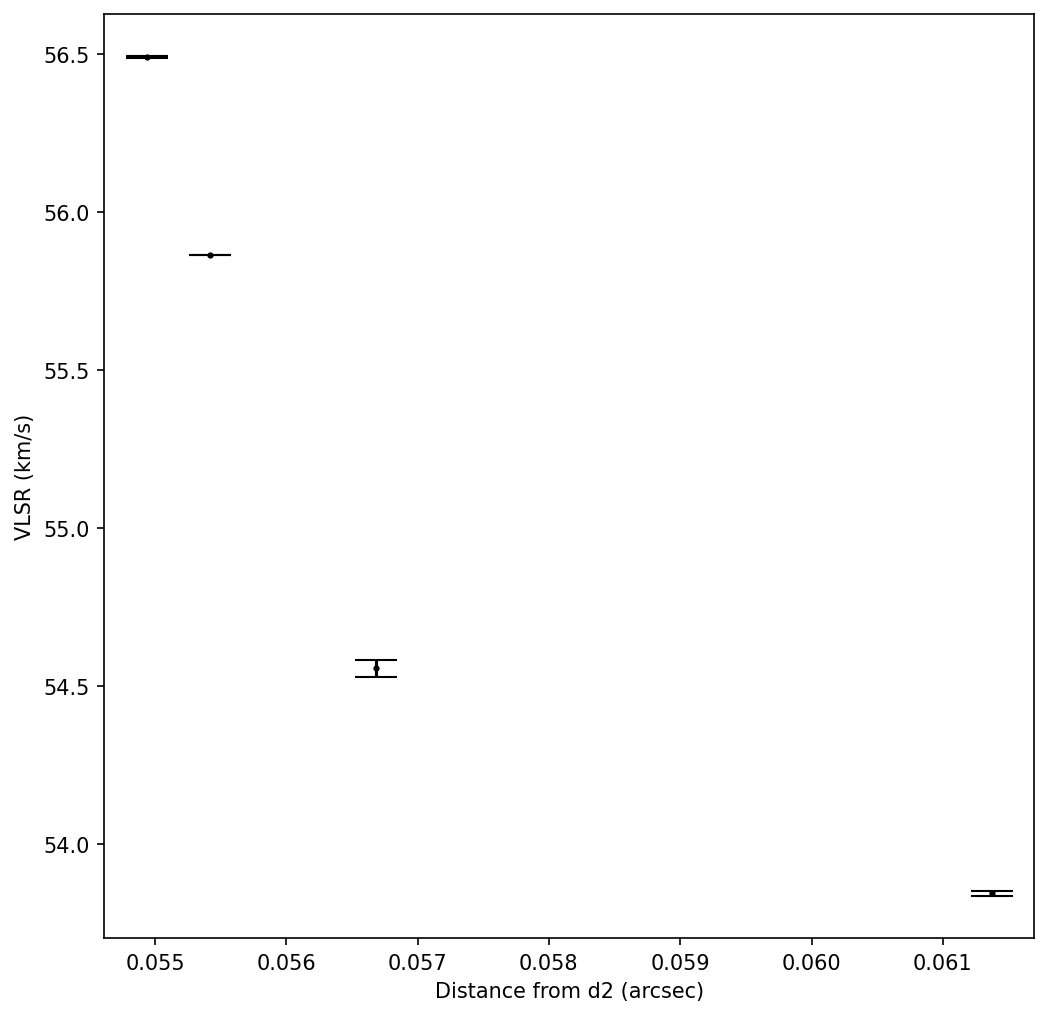

In [37]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

ax.errorbar(distance_from_d2, d2_vlsr, yerr=d2_vlsr_err, marker='o', color='black',markersize=2, linestyle='none', capsize=10)
ax.set_xlabel('Distance from d2 (arcsec)')
ax.set_ylabel('VLSR (km/s)')